<a href="https://colab.research.google.com/github/kholoud400/ML-NN-CNN-projects/blob/main/Cars_Price_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv('/content/cars_data.csv')

In [ ]:
df.head()

,Brand,Year,Mileage,Engine_Size,Fuel_Type,Transmission,Previous_Owners,Price
0,Kia,2015.0,110373.0,2.5,Electric,Manual,2,3000.0
1,Mercedes,2010.0,186144.0,1.3,Electric,Manual,5,4844.0
2,Nissan,2018.0,29574.0,2.6,Petrol,Manual,1,6628.0
3,Kia,2010.0,139502.0,2.4,Diesel,Automatic,NaN,3000.0
4,BMW,2014.0,148748.0,3.5,Diesel,Manual,1,6451.0


In [ ]:
df.shape

(1000, 8)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Brand            979 non-null    object 
 1   Year             974 non-null    float64
 2   Mileage          979 non-null    float64
 3   Engine_Size      964 non-null    float64
 4   Fuel_Type        982 non-null    object 
 5   Transmission     962 non-null    object 
 6   Previous_Owners  950 non-null    object 
 7   Price            987 non-null    float64
dtypes: float64(4), object(4)
memory usage: 62.6+ KB


In [ ]:
df.describe()

,Year,Mileage,Engine_Size,Price
count,974.000000,979.000000,964.000000,987.000000
mean,2016.320329,104185.955056,2.490560,8473.716312
std,4.050561,56333.931315,0.866082,6301.920977
min,2010.000000,5207.000000,1.000000,3000.000000
25%,2013.000000,54002.500000,1.800000,4068.000000
50%,2016.000000,104853.000000,2.500000,6426.000000
75%,2020.000000,155030.000000,3.200000,10917.000000
max,2023.000000,199812.000000,4.000000,43994.000000


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
x=df.drop('Price',axis=1)
y=df['Price']

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [ ]:
x_train.isnull().sum()

,0
Brand,16
Year,16
Mileage,14
Engine_Size,25
Fuel_Type,12
Transmission,29
Previous_Owners,37


In [ ]:
from sklearn.impute import SimpleImputer

In [ ]:
imputer_numerical = SimpleImputer(strategy='median')
x_train[['Year', 'Mileage', 'Engine_Size']] = imputer_numerical.fit_transform(x_train[['Year', 'Mileage', 'Engine_Size']])
x_test[['Year', 'Mileage', 'Engine_Size']] = imputer_numerical.transform(x_test[['Year', 'Mileage', 'Engine_Size']])
imputer_categorical = SimpleImputer(strategy='most_frequent')
x_train[['Brand','Previous_Owners','Transmission','Fuel_Type']] = imputer_categorical.fit_transform(x_train[['Brand','Previous_Owners','Transmission','Fuel_Type']])
x_test[['Brand','Previous_Owners','Transmission','Fuel_Type']] = imputer_categorical.transform(x_test[['Brand','Previous_Owners','Transmission','Fuel_Type']])
y_train = y_train.fillna(y_train.median())
y_test = y_test.fillna(y_test.median())

In [ ]:
x_train.isnull().sum()

,0
Brand,0
Year,0
Mileage,0
Engine_Size,0
Fuel_Type,0
Transmission,0
Previous_Owners,0


In [ ]:
y_train.isnull().sum()

np.int64(0)

In [ ]:
df['Price'] = df['Price'].fillna(df['Price'].median())

In [ ]:
x_train.reset_index(drop=True,inplace=True)
x_test.reset_index(drop=True,inplace=True)
y_train.reset_index(drop=True,inplace=True)
y_test.reset_index(drop=True,inplace=True)

<Axes: xlabel='Brand', ylabel='count'>

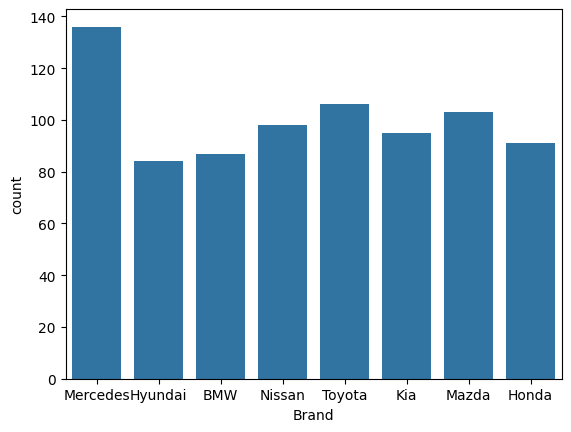

In [ ]:
sns.countplot(x='Brand',data=x_train)

<Axes: xlabel='Year', ylabel='Price'>

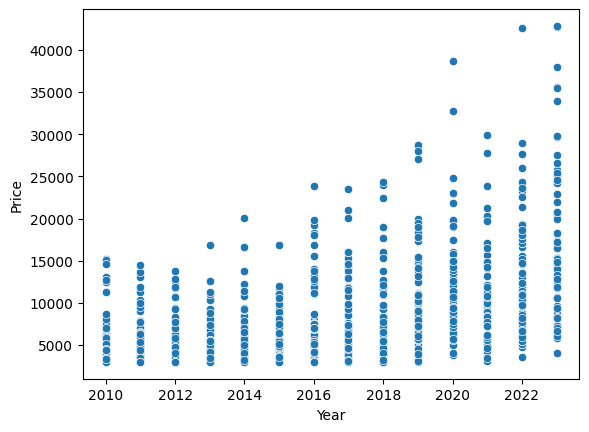

In [ ]:
sns.scatterplot(x='Year',y='Price',data=df)

<Axes: xlabel='Brand', ylabel='Price'>

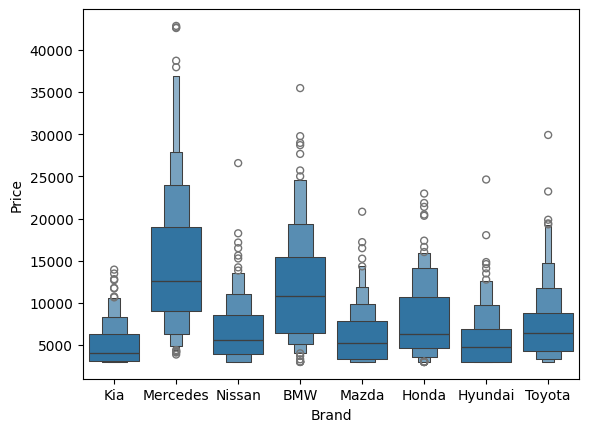

In [ ]:
sns.boxenplot(x='Brand',y='Price',data=df)

In [ ]:
x_train.select_dtypes(include='object')

,Brand,Fuel_Type,Transmission,Previous_Owners
0,Mercedes,Diesel,Automatic,2
1,Hyundai,Diesel,Manual,3
2,Mercedes,Hybrid,Manual,5
3,Hyundai,Electric,Automatic,4
4,BMW,Diesel,Automatic,5
...,...,...,...,...
795,Hyundai,Electric,Automatic,2
796,Hyundai,Hybrid,Manual,5
797,Mercedes,Electric,Automatic,1
798,Mazda,Petrol,Automatic,5


In [ ]:
x_train.shape

(800, 7)

In [ ]:
x_test.shape

(200, 7)

In [ ]:
from sklearn.preprocessing import OneHotEncoder

In [ ]:
for col in x_train.select_dtypes(include='object').columns:

    oh = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    encoded_train = oh.fit_transform(x_train[[col]])
    encoded_test = oh.transform(x_test[[col]])

    cols = oh.get_feature_names_out([col])

    encoded_train_df = pd.DataFrame(encoded_train, columns=cols, index=x_train.index)
    encoded_test_df = pd.DataFrame(encoded_test, columns=cols, index=x_test.index)

    x_train = pd.concat([x_train.drop(col, axis=1), encoded_train_df], axis=1)
    x_test = pd.concat([x_test.drop(col, axis=1), encoded_test_df], axis=1)

/tmp/ipykernel_7015/1425367654.py:2: FutureWarning: Series.ravel is deprecated. The underlying array is already 1D, so ravel is not necessary.  Use `to_numpy()` for conversion to a numpy array instead.
  sns.heatmap(pd.concat([x_train,pd.Series(y_train.ravel())],axis=1).corr(),annot=True)


<Axes: >

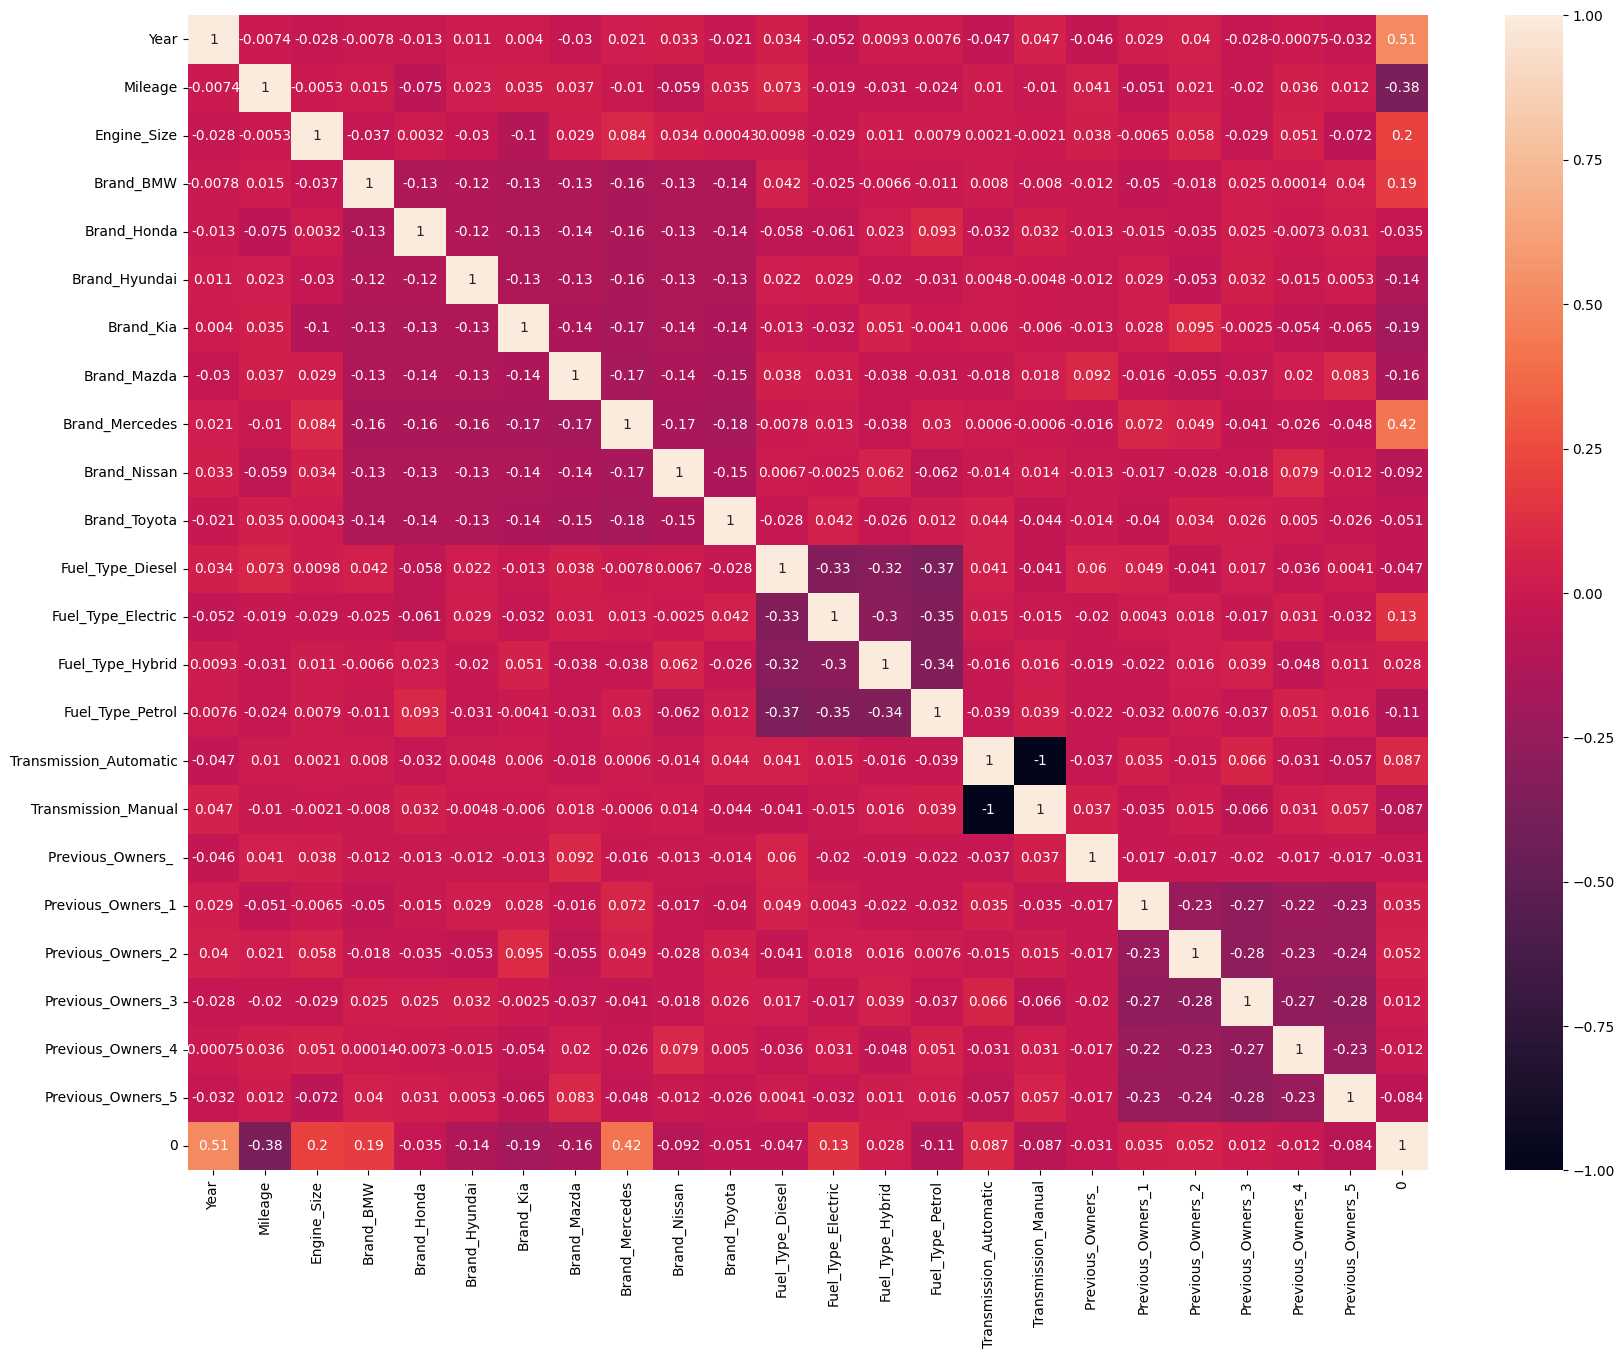

In [ ]:
plt.figure(figsize=(20, 15))
sns.heatmap(pd.concat([x_train,pd.Series(y_train.ravel())],axis=1).corr(),annot=True)

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
sc=StandardScaler()
x_train=sc.fit_transform(x_train)
x_test=sc.transform(x_test)

In [ ]:
from sklearn.linear_model import LinearRegression

In [ ]:
model=LinearRegression()
model.fit(x_train,y_train)

LinearRegression()

In [ ]:
y_pred=model.predict(x_test)


In [ ]:
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error,mean_absolute_percentage_error


In [ ]:
mse=mean_squared_error(y_test,y_pred)
print('MSE:',mse)
rmse=np.sqrt(mse)
print('RMSE:',rmse)
mae=mean_absolute_error(y_test,y_pred)
print('MAE:',mae)
mape=mean_absolute_percentage_error(y_test,y_pred)
print('MAPE:',mape)
r2=r2_score(y_test,y_pred)
print('R2:',r2)

MSE: 12036377.14667537
RMSE: 3469.3482308173348
MAE: 2183.084393957781
MAPE: 0.33970001016802165
R2: 0.6971755395366228


In [ ]:
from sklearn.neighbors import KNeighborsRegressor

In [ ]:
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error,mean_absolute_percentage_error

In [ ]:
model=KNeighborsRegressor(n_neighbors=5,metric='minkowski',p=2)
model.fit(x_train,y_train)
mae=mean_absolute_error(y_test,y_pred)
print('MAE:',mae)
mape=mean_absolute_percentage_error(y_test,y_pred)
print('MAPE:',mape)
r2=r2_score(y_test,y_pred)
print('R2:',r2)


MAE: 2183.084393957781
MAPE: 0.33970001016802165
R2: 0.6971755395366228


In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.layers import Dense
from tensorflow.keras.models import Sequential

In [ ]:
model = Sequential()
model.add(Dense(100, activation="relu", input_shape = x_train.shape[1:]))  # input_dim = 8 X_train.shape[1]
model.add(Dense(25, activation=tf.keras.activations.relu))
model.add(Dense(25, activation="relu"))
model.add(Dense(25, activation="relu"))
model.add(Dense(25, activation="relu"))
model.add(Dense(8, activation="relu"))
model.add(Dense(1, activation="relu")) # price > 0, so, relu

# The model’s summary() method displays all the model’s layers
print(model.summary())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_7 (Dense)                 │ (None, 100)            │         2,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 25)             │         2,525 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 25)             │           650 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 25)             │           650 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 25)             │           650 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 8)              │           208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,092 (27.70 KB)

 Trainable params: 7,092 (27.70 KB)

 Non-trainable params: 0 (0.00 B)

None


In [ ]:
model.compile(loss="mean_squared_error", optimizer="adam", metrics=["mae"])

In [ ]:
history = model.fit(x_train, y_train, epochs=30, batch_size=128, validation_split=0.2)

Epoch 1/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 113ms/step - loss: 113426432.0000 - mae: 8553.5020 - val_loss: 99794200.0000 - val_mae: 8100.7900
Epoch 2/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 113421376.0000 - mae: 8553.1973 - val_loss: 99788048.0000 - val_mae: 8100.4194
Epoch 3/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - loss: 113413680.0000 - mae: 8552.7598 - val_loss: 99778376.0000 - val_mae: 8099.8330
Epoch 4/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 113401264.0000 - mae: 8552.0596 - val_loss: 99762368.0000 - val_mae: 8098.8779
Epoch 5/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - loss: 113381224.0000 - mae: 8550.9316 - val_loss: 99737296.0000 - val_mae: 8097.3857
Epoch 6/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - loss: 113349528.0000 - mae: 8549.1797 - val_loss: 99698104.0000 - val_mae: 8095.0674
Epoch 7/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - loss: 113301296.0000 - mae: 8546.4473 - val_loss: 99637272.0000 - val_mae: 8091.4912
Epoch 8/30
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/ste